# Projeto G1 — Mercado de TI no Brasil

## 1. Introdução ao problema

Este projeto analisa uma base **simulada** do mercado de Tecnologia da Informação no Brasil entre 2015 e 2024. O objetivo é identificar padrões de remuneração, distribuição de vagas e diferenças associadas a região, cargo, senioridade, tecnologia, modalidade de trabalho, setor e nível de demanda.

As conclusões são válidas para o conjunto de dados analisado e não representam estatísticas oficiais do mercado brasileiro.

## 2. Base de dados

A base contém registros mensais com informações geográficas, profissionais e indicadores quantitativos. As principais variáveis são:

- `data`, `ano`, `mes`: dimensão temporal;
- `regiao`, `uf`, `cidade`: dimensão geográfica;
- `cargo`, `senioridade`, `tecnologia`: perfil profissional;
- `modalidade`: presencial, híbrido ou remoto;
- `salario_medio`: remuneração média registrada;
- `quantidade_vagas`: volume de vagas;
- `empresa_setor`: setor econômico;
- `nivel_demanda`: classificação de demanda.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
CSV_PATH = ROOT / 'dados' / 'simulacao_mercado_ti_brasil.csv'
DB_PATH = ROOT / 'database' / 'mercado_ti.db'

CSV_PATH

PosixPath('/mnt/data/projeto-g1/dados/simulacao_mercado_ti_brasil.csv')

## 3. Leitura dos dados

In [2]:
df = pd.read_csv(CSV_PATH, parse_dates=['data'])
df.head()

,ano,mes,data,regiao,uf,cidade,cargo,senioridade,tecnologia,modalidade,salario_medio,quantidade_vagas,empresa_setor,nivel_demanda
0,2015,1,2015-01-01,Norte,AM,Manaus,Cientista de Dados,Sênior,Java,Presencial,7919.27,40,Fintech,Baixo
1,2015,1,2015-01-01,Norte,PA,Belém,Cientista de Dados,Pleno,AWS,Presencial,9477.26,37,Varejo,Alto
2,2015,1,2015-01-01,Norte,PA,Santarém,Cientista de Dados,Sênior,Java,Híbrido,17314.96,45,Governo,Crítico
3,2015,1,2015-01-01,Norte,RO,Porto Velho,Analista de Dados,Sênior,Java,Remoto,9215.33,43,Saúde,Médio
4,2015,1,2015-01-01,Norte,TO,Palmas,Dev Backend,Pleno,SQL,Remoto,8810.91,44,Saúde,Alto


In [3]:
print('Dimensões:', df.shape)
print('Período:', df['data'].min().date(), 'a', df['data'].max().date())
df.info()

Dimensões: (4440, 14)
Período: 2015-01-01 a 2024-12-01
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ano               4440 non-null   int64         
 1   mes               4440 non-null   int64         
 2   data              4440 non-null   datetime64[ns]
 3   regiao            4440 non-null   object        
 4   uf                4440 non-null   object        
 5   cidade            4440 non-null   object        
 6   cargo             4440 non-null   object        
 7   senioridade       4440 non-null   object        
 8   tecnologia        4440 non-null   object        
 9   modalidade        4440 non-null   object        
 10  salario_medio     4440 non-null   float64       
 11  quantidade_vagas  4440 non-null   int64         
 12  empresa_setor     4440 non-null   object        
 13  nivel_demanda     4440 

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
ano,4440.0,NaN,NaN,NaN,2019.5,2015.0,2017.0,2019.5,2022.0,2024.0,2.872605
mes,4440.0,NaN,NaN,NaN,6.5,1.0,3.75,6.5,9.25,12.0,3.452441
data,4440,NaN,NaN,NaN,2019-12-16 10:48:00,2015-01-01 00:00:00,2017-06-23 12:00:00,2019-12-16 12:00:00,2022-06-08 12:00:00,2024-12-01 00:00:00,NaN
regiao,4440,5,Sudeste,1560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
uf,4440,20,RJ,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cidade,4440,37,Manaus,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cargo,4440,5,Cientista de Dados,930,NaN,NaN,NaN,NaN,NaN,NaN,NaN
senioridade,4440,3,Júnior,1515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tecnologia,4440,6,Java,770,NaN,NaN,NaN,NaN,NaN,NaN,NaN
modalidade,4440,3,Remoto,1517,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Limpeza e preparação

A preparação valida duplicidades, valores ausentes, tipos e limites das métricas. A coluna temporal é convertida para `datetime`; dimensões categóricas podem ser armazenadas como `category` para reduzir memória e explicitar sua natureza categórica.

In [5]:
print('Valores ausentes por coluna:')
display(df.isna().sum())
print('Linhas duplicadas:', df.duplicated().sum())

# Garantias básicas
df['data'] = pd.to_datetime(df['data'], errors='coerce')
df['ano'] = df['data'].dt.year
df['mes'] = df['data'].dt.month

categoricas = ['regiao','uf','cidade','cargo','senioridade','tecnologia','modalidade','empresa_setor','nivel_demanda']
for col in categoricas:
    df[col] = df[col].astype('category')

df['salario_medio'] = pd.to_numeric(df['salario_medio'], errors='coerce')
df['quantidade_vagas'] = pd.to_numeric(df['quantidade_vagas'], errors='coerce')

print('Valores inválidos em salário:', (df['salario_medio'] <= 0).sum())
print('Valores inválidos em vagas:', (df['quantidade_vagas'] < 0).sum())
print('Memória após tipagem:', round(df.memory_usage(deep=True).sum()/1024**2, 2), 'MB')

Valores ausentes por coluna:


ano                 0
mes                 0
data                0
regiao              0
uf                  0
cidade              0
cargo               0
senioridade         0
tecnologia          0
modalidade          0
salario_medio       0
quantidade_vagas    0
empresa_setor       0
nivel_demanda       0
dtype: int64

Linhas duplicadas: 0
Valores inválidos em salário: 0
Valores inválidos em vagas: 0
Memória após tipagem: 0.18 MB


## 5. Engenharia de atributos

In [6]:
df['trimestre'] = df['data'].dt.to_period('Q').astype(str)
df['salario_total_estimado'] = df['salario_medio'] * df['quantidade_vagas']

ordem_senioridade = pd.CategoricalDtype(['Júnior','Pleno','Sênior'], ordered=True)
df['senioridade'] = df['senioridade'].astype(ordem_senioridade)

ordem_demanda = pd.CategoricalDtype(['Baixo','Médio','Alto','Crítico'], ordered=True)
df['nivel_demanda'] = df['nivel_demanda'].astype(ordem_demanda)
df[['data','trimestre','salario_total_estimado']].head()

,data,trimestre,salario_total_estimado
0,2015-01-01,2015Q1,316770.80
1,2015-01-01,2015Q1,350658.62
2,2015-01-01,2015Q1,779173.20
3,2015-01-01,2015Q1,396259.19
4,2015-01-01,2015Q1,387680.04


## 6. Análise exploratória

### 6.1 Distribuições principais

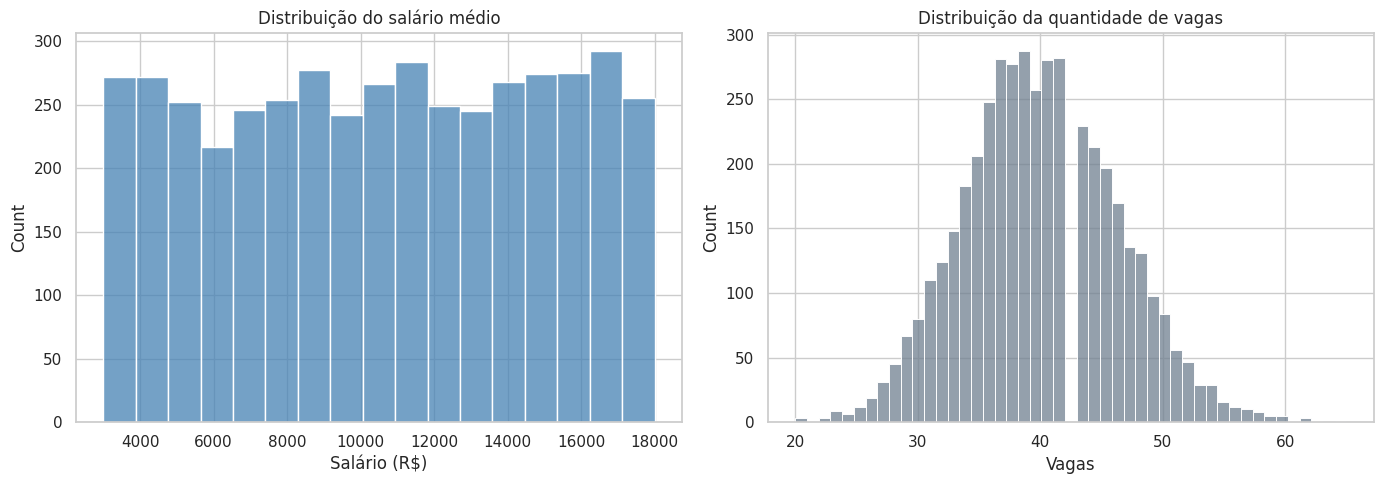

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(df['salario_medio'], kde=False, color='steelblue', ax=axes[0])
axes[0].set_title('Distribuição do salário médio')
axes[0].set_xlabel('Salário (R$)')

sns.histplot(df['quantidade_vagas'], kde=False, color='slategray', ax=axes[1])
axes[1].set_title('Distribuição da quantidade de vagas')
axes[1].set_xlabel('Vagas')
plt.tight_layout()

### 6.2 Comparação por região

In [8]:
regiao = df.groupby('regiao', observed=True).agg(
    salario_medio=('salario_medio','mean'),
    vagas=('quantidade_vagas','sum')
).sort_values('salario_medio', ascending=False)
regiao.round(2)

,salario_medio,vagas
regiao,,
Centro-Oeste,10899.75,23938
Sul,10765.67,29105
Sudeste,10572.65,62623
Nordeste,10461.38,38230
Norte,10328.48,23723


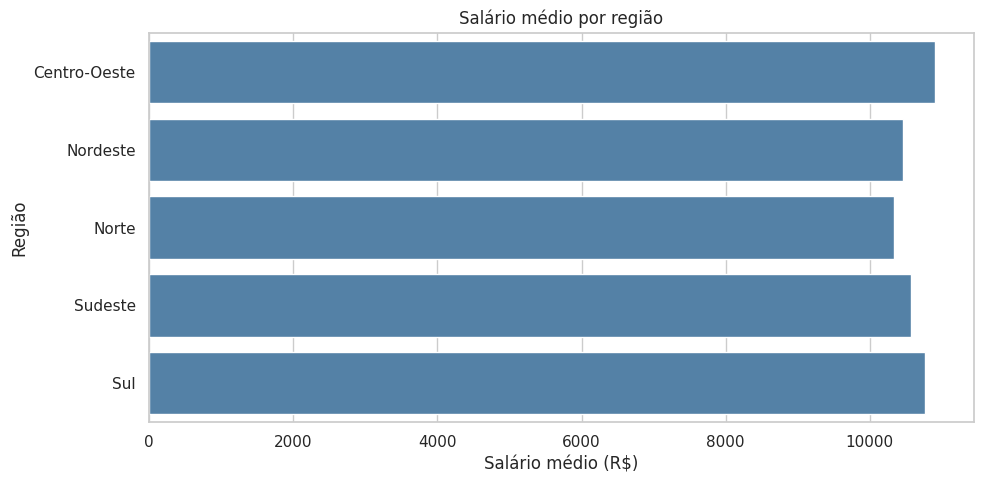

In [9]:
plt.figure(figsize=(10,5))
sns.barplot(data=regiao.reset_index(), x='salario_medio', y='regiao', color='steelblue')
plt.title('Salário médio por região')
plt.xlabel('Salário médio (R$)')
plt.ylabel('Região')
plt.tight_layout()

### 6.3 Cargos e senioridade

In [10]:
cargo = df.groupby('cargo', observed=True).agg(
    salario_medio=('salario_medio','mean'),
    vagas=('quantidade_vagas','sum')
).sort_values('salario_medio', ascending=False)
cargo.round(2)

,salario_medio,vagas
cargo,,
Dev Backend,10714.08,36246
Analista de Dados,10631.34,34278
Cientista de Dados,10597.60,37249
Dev Frontend,10562.54,36251
DevOps,10440.17,33595


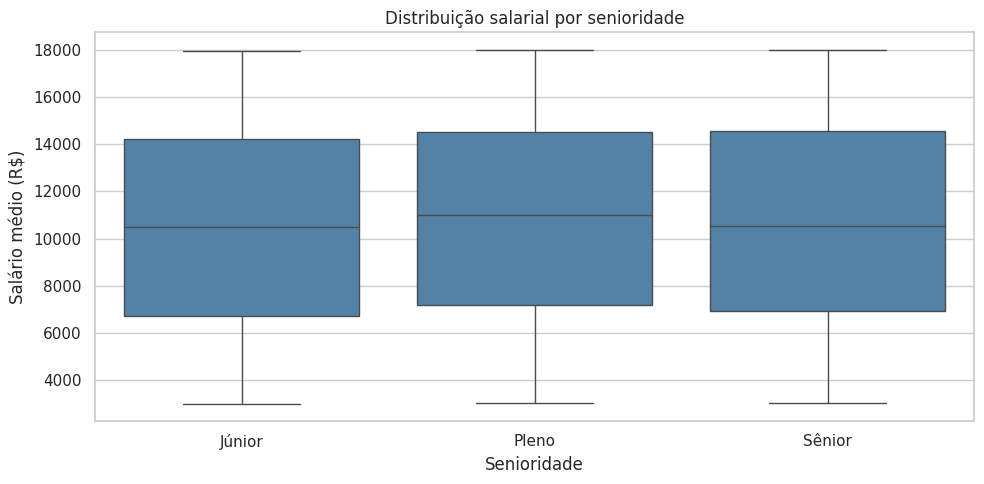

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='senioridade', y='salario_medio', order=['Júnior','Pleno','Sênior'], color='steelblue')
plt.title('Distribuição salarial por senioridade')
plt.xlabel('Senioridade')
plt.ylabel('Salário médio (R$)')
plt.tight_layout()

### 6.4 Tecnologias

In [12]:
tecnologia = df.groupby('tecnologia', observed=True).agg(
    salario_medio=('salario_medio','mean'),
    vagas=('quantidade_vagas','sum')
).sort_values('salario_medio', ascending=False)
tecnologia.round(2)

,salario_medio,vagas
tecnologia,,
Java,10760.54,30631
AWS,10617.65,29569
Power BI,10576.91,30310
SQL,10547.57,28585
JavaScript,10541.58,29972
Python,10490.78,28552


### 6.5 Modalidade de trabalho

In [13]:
modalidade = df.groupby('modalidade', observed=True).agg(
    salario_medio=('salario_medio','mean'),
    vagas=('quantidade_vagas','sum')
).sort_values('salario_medio', ascending=False)
modalidade.round(2)

,salario_medio,vagas
modalidade,,
Híbrido,10648.07,58824
Remoto,10618.23,60966
Presencial,10504.74,57829


## 7. KPIs

In [14]:
kpis = {
    'Salário médio geral': df['salario_medio'].mean(),
    'Mediana salarial': df['salario_medio'].median(),
    'Vagas acumuladas': df['quantidade_vagas'].sum(),
    'Registros': len(df),
    'Cidades': df['cidade'].nunique(),
    'Ufs': df['uf'].nunique(),
}
pd.Series(kpis).round(2)

Salário médio geral     10591.10
Mediana salarial        10692.04
Vagas acumuladas       177619.00
Registros                4440.00
Cidades                    37.00
Ufs                        20.00
dtype: float64

## 8. Análise temporal

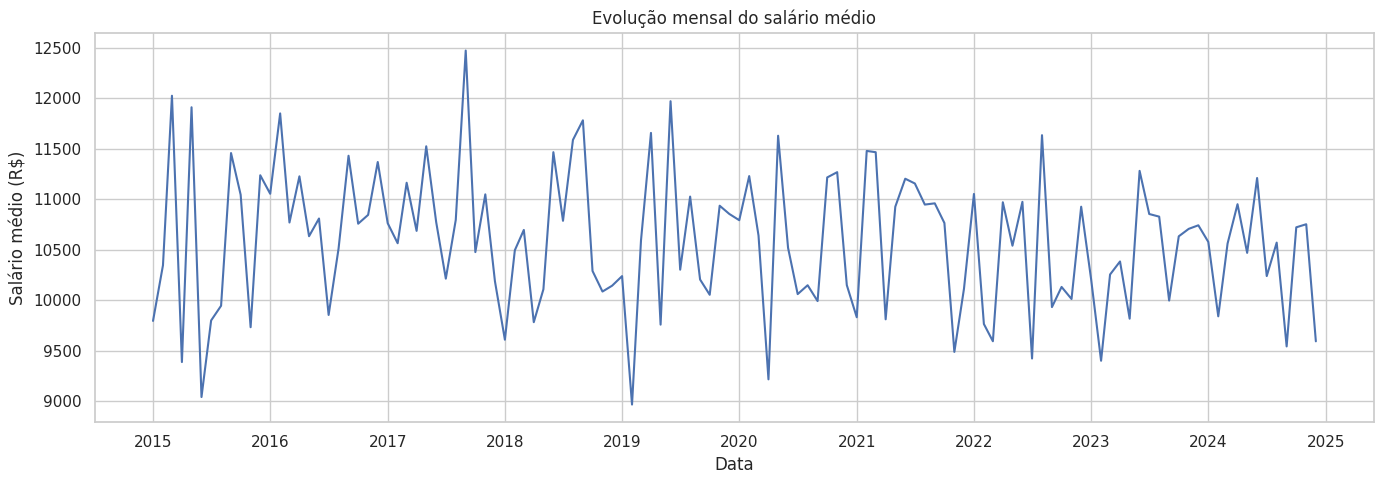

In [15]:
temporal = df.groupby('data', as_index=False).agg(
    salario_medio=('salario_medio','mean'),
    vagas=('quantidade_vagas','sum')
)
fig, ax1 = plt.subplots(figsize=(14,5))
ax1.plot(temporal['data'], temporal['salario_medio'])
ax1.set_ylabel('Salário médio (R$)')
ax1.set_xlabel('Data')
ax1.set_title('Evolução mensal do salário médio')
plt.tight_layout()

In [16]:
anual = df.groupby('ano', as_index=False).agg(
    salario_medio=('salario_medio','mean'),
    vagas=('quantidade_vagas','sum')
)
anual['variacao_salarial_%'] = anual['salario_medio'].pct_change()*100
anual.round(2)

,ano,salario_medio,vagas,variacao_salarial_%
0,2015,10476.19,17805,NaN
1,2016,10925.99,17918,4.29
2,2017,10888.98,17737,-0.34
3,2018,10568.82,17944,-2.94
4,2019,10546.36,17883,-0.21
5,2020,10571.21,17458,0.24
6,2021,10678.32,17766,1.01
7,2022,10412.06,17670,-2.49
8,2023,10424.68,17864,0.12
9,2024,10418.36,17574,-0.06


## 9. Correlação estatística

In [17]:
corr = df[['salario_medio','quantidade_vagas']].corr()
corr

,salario_medio,quantidade_vagas
salario_medio,1.000000,0.015535
quantidade_vagas,0.015535,1.000000


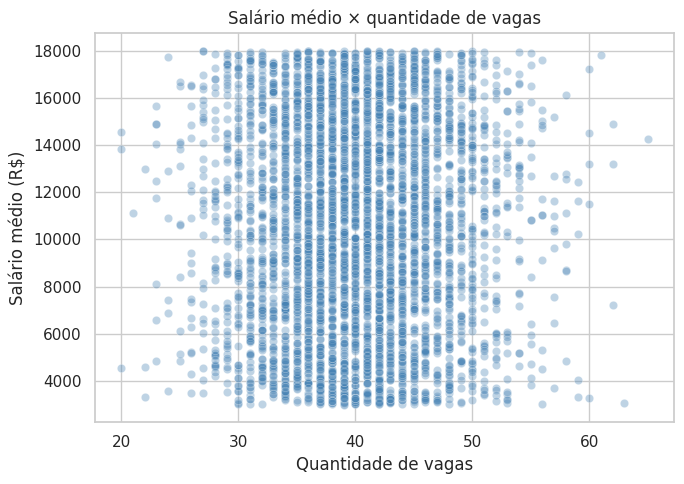

In [18]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='quantidade_vagas', y='salario_medio', alpha=.35, color='steelblue')
plt.title('Salário médio × quantidade de vagas')
plt.xlabel('Quantidade de vagas')
plt.ylabel('Salário médio (R$)')
plt.tight_layout()

## 10. Integração com SQLite + SQLAlchemy

A base tratada é persistida em SQLite. O dashboard utiliza o mesmo banco para separar a camada de armazenamento da camada de apresentação.

In [19]:
engine = create_engine(f'sqlite:///{DB_PATH}', future=True)
df.to_sql('mercado_ti', engine, if_exists='replace', index=False)
print('Tabela mercado_ti criada em:', DB_PATH)

Tabela mercado_ti criada em: /mnt/data/projeto-g1/database/mercado_ti.db


## 11. Interpretação dos resultados

Na base analisada, o **Centro-Oeste** apresenta a maior média salarial regional, enquanto o **Sudeste** concentra o maior volume acumulado de vagas. Entre os cargos, **Dev Backend** apresenta a maior média salarial. Entre as tecnologias, **Java** possui a maior média salarial agregada. A modalidade **Híbrido** apresenta a maior média entre as três modalidades.

A correlação entre salário médio e quantidade de vagas é próxima de zero (`r ≈ 0,016`), indicando ausência de relação linear relevante entre essas duas variáveis no dataset. Isso não significa que não existam relações condicionais por cargo, região ou senioridade.

## 12. Conclusão

O projeto demonstra um fluxo completo de análise de dados: leitura, validação, limpeza, tipagem, engenharia de atributos, análise exploratória, KPIs, visualização estatística, análise temporal, correlação, persistência em banco e disponibilização em dashboard.

O Streamlit complementa o notebook com filtros e visualizações interativas, permitindo que o usuário explore diferentes recortes da base. A página HTML resume o projeto e funciona como apresentação para publicação no GitHub Pages.